In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier , DecisionTreeRegressor
import pandas as pd
import numpy as np

In [ ]:
data = load_iris()

In [ ]:
X = data.data
y = data.target

In [ ]:
model = DecisionTreeClassifier()

In [ ]:
from sklearn.model_selection import train_test_split , cross_val_score

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [ ]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(cross_val_score(model , X_train, y_train, cv=10))

[0.91666667 1.         1.         1.         0.66666667 0.83333333
 1.         0.91666667 0.91666667 0.91666667]


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
from sklearn.tree import plot_tree

In [ ]:
model = DecisionTreeRegressor()
model = model.fit(X_train,y_train)

[Text(0.3076923076923077, 0.9285714285714286, 'x[3] <= 0.8\nsquared_error = 0.658\nsamples = 120\nvalue = 0.992'),
 Text(0.23076923076923078, 0.7857142857142857, 'squared_error = 0.0\nsamples = 40\nvalue = 0.0'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'x[2] <= 4.75\nsquared_error = 0.25\nsamples = 80\nvalue = 1.488'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[3] <= 1.65\nsquared_error = 0.026\nsamples = 37\nvalue = 1.027'),
 Text(0.07692307692307693, 0.5, 'squared_error = 0.0\nsamples = 36\nvalue = 1.0'),
 Text(0.23076923076923078, 0.5, 'squared_error = 0.0\nsamples = 1\nvalue = 2.0'),
 Text(0.6153846153846154, 0.6428571428571429, 'x[3] <= 1.75\nsquared_error = 0.103\nsamples = 43\nvalue = 1.884'),
 Text(0.38461538461538464, 0.5, 'x[2] <= 4.95\nsquared_error = 0.25\nsamples = 8\nvalue = 1.5'),
 Text(0.3076923076923077, 0.35714285714285715, 'squared_error =

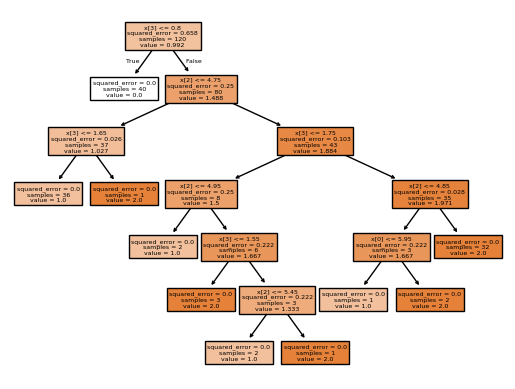

In [ ]:
plot_tree(model,filled=True)

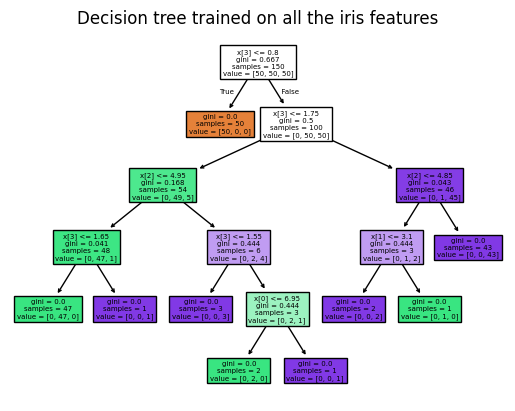

In [ ]:
plt.figure()
clf = DecisionTreeClassifier().fit(data.data, data.target)
plot_tree(clf, filled=True)
plt.title("Decision tree trained on all the iris features")
plt.show()

In [ ]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

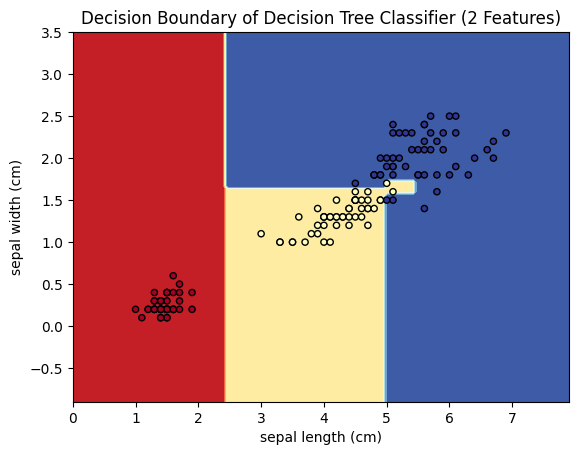

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

# Let's use the first two features (sepal width and sepal pattle length)
X_2d = X[:, 2:]
y_2d = y

# Create and train a DecisionTreeClassifier on the 2D data
model_2d = DecisionTreeClassifier(random_state=42)
model_2d.fit(X_2d, y_2d)

# Plot the decision boundary
display = DecisionBoundaryDisplay.from_estimator(
    model_2d, X_2d, cmap=plt.cm.RdYlBu, response_method="predict",
    xlabel=data.feature_names[0], ylabel=data.feature_names[1]
)

# Add the training points to the plot
display.ax_.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap=plt.cm.RdYlBu, edgecolor='k', s=20)

plt.title("Decision Boundary of Decision Tree Classifier (2 Features)")
plt.show()

In [ ]:
import seaborn as sns
data = sns.load_dataset('penguins')

In [ ]:
data.dropna(inplace=True)

In [55]:
X = data.drop(columns=['species'])
y = data['species']

In [56]:
from sklearn.preprocessing import LabelEncoder

In [57]:
y_enoded = LabelEncoder().fit_transform(y)

In [60]:
model = DecisionTreeClassifier()

In [67]:
X_encoded = pd.get_dummies(X, columns=['island', 'sex'], drop_first=True)
X_train , X_test , y_train , y_test = train_test_split(X_encoded,y_enoded,test_size=0.2,random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [68]:
y_pred = model.predict(X_test)

In [78]:
print(cross_val_score(model , X_train, y_train, cv=10))

[0.96296296 0.92592593 0.92592593 0.92592593 1.         0.92592593
 1.         0.96153846 0.92307692 1.        ]


In [69]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


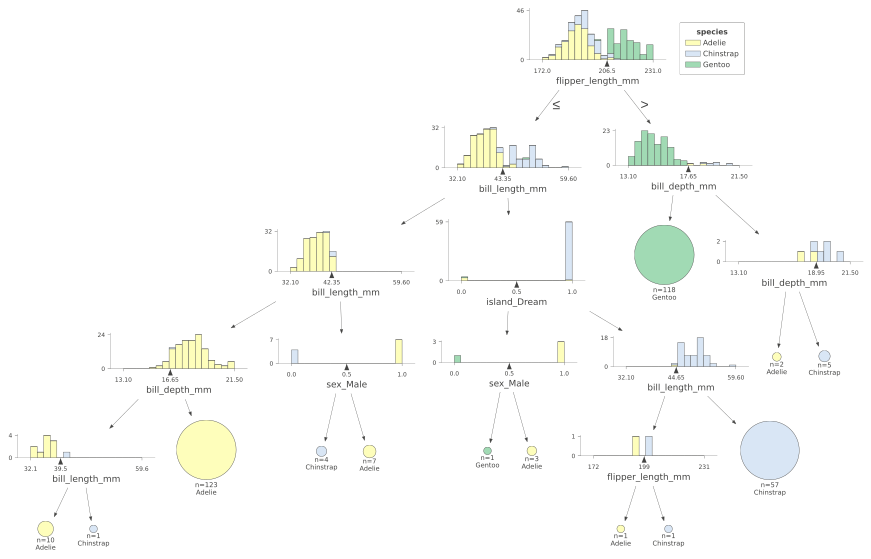

In [75]:
import dtreeviz

viz_model = dtreeviz.model(
    model,
    X_encoded,
    y_enoded,
    target_name='species',
    feature_names=X_encoded.columns,
    class_names=list(data['species'].unique())
)
viz_model.view()

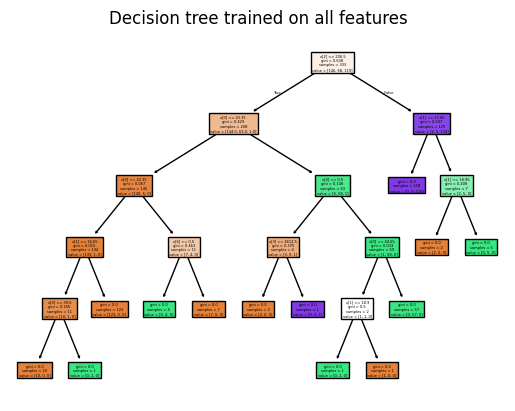

In [77]:
plt.figure()
model = DecisionTreeClassifier().fit(X_encoded,y_enoded)
plot_tree(model, filled=True)
plt.title("Decision tree trained on all features")
plt.show()

In [79]:
df = sns.load_dataset('titanic')

In [110]:
df = df.drop(columns=['alive'])

In [83]:
df['age'].fillna(df['age'].mean(),inplace=True)

/tmp/ipykernel_6307/1492264711.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




In [89]:
df.dropna(inplace=True)

In [111]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,False


In [112]:
X = df.drop(columns='survived')
y =df['survived']

In [132]:
X_encoded = pd.get_dummies(X, columns=['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone'], drop_first=True)
y_encoded = LabelEncoder().fit_transform(y)

In [175]:
model = DecisionTreeClassifier()

In [176]:
X_test,X_train,y_test,y_train = train_test_split(X_encoded,y_encoded,test_size=0.2,random_state=42)

In [177]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [178]:
model.feature_importances_

array([0.        , 0.03967742, 0.08397337, 0.        , 0.18810036,
       0.        , 0.        , 0.        , 0.06612903, 0.        ,
       0.        , 0.45540797, 0.        , 0.16671185, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        ])

In [179]:
y_pred = model.predict(X_test)

In [180]:
print(cross_val_score(model , X_train, y_train, cv=10))
print(classification_report(y_test,y_pred))

[1.   0.5  0.75 0.75 0.75 0.75 1.   0.75 1.   0.5 ]
              precision    recall  f1-score   support

           0       0.57      0.71      0.63        58
           1       0.81      0.70      0.75       103

    accuracy                           0.70       161
   macro avg       0.69      0.70      0.69       161
weighted avg       0.72      0.70      0.71       161



Visualizing decision boundary using top two features: 'fare' and 'who_man'


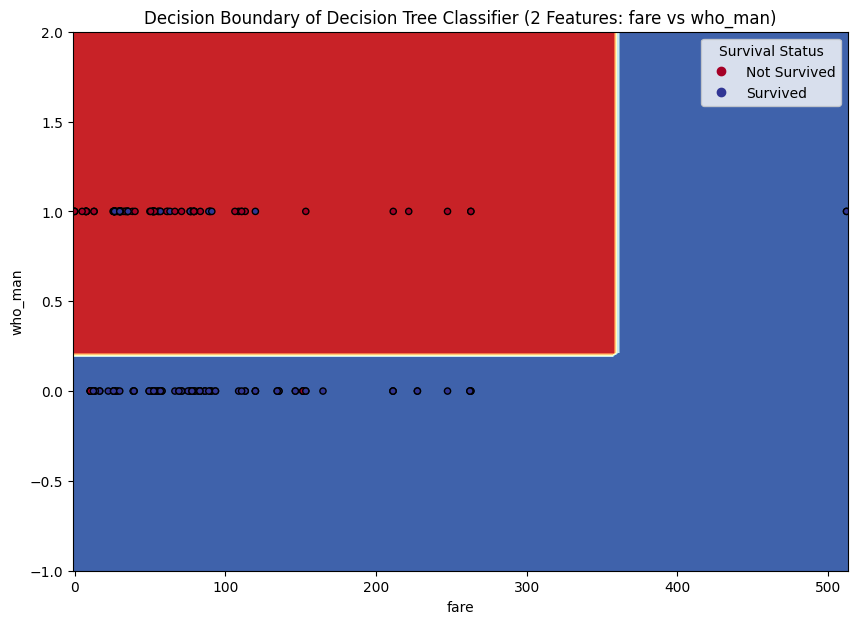

In [167]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Train a temporary model on the entire encoded dataset to get feature importances for all columns
# This ensures that feature_importances_ correctly corresponds to X_encoded.columns
temp_model_for_importance = DecisionTreeClassifier(splitter='random', random_state=42) # Using same params as your model
temp_model_for_importance.fit(X_encoded, y_encoded)

feature_importances = temp_model_for_importance.feature_importances_
feature_names = X_encoded.columns

# Get indices of top 2 features based on importance
top_2_indices = np.argsort(feature_importances)[-2:]
feature1_idx, feature2_idx = top_2_indices[0], top_2_indices[1]

# Retrieve the names of the top 2 features
feature1_name = feature_names[feature1_idx]
feature2_name = feature_names[feature2_idx]

print(f"Visualizing decision boundary using top two features: '{feature1_name}' and '{feature2_name}'")

# Create a 2D subset of the data using these top 2 features
X_2d_selected = X_encoded[[feature1_name, feature2_name]]

# Train a new DecisionTreeClassifier specifically for these two features
# This model will be used only for visualizing the 2D decision boundary.
model_2d_boundary = DecisionTreeClassifier(splitter='random', max_depth=4, random_state=42) # Using same params as your model
model_2d_boundary.fit(X_2d_selected, y_encoded)

# Set up the plot
plt.figure(figsize=(10, 7))

# Plot the decision boundary
display = DecisionBoundaryDisplay.from_estimator(
    model_2d_boundary,
    X_2d_selected,
    cmap=plt.cm.RdYlBu,
    response_method="predict",
    xlabel=feature1_name,
    ylabel=feature2_name,
    ax=plt.gca()
)

# Overlay the original data points
# y_encoded contains 0 (Not Survived) and 1 (Survived)
scatter = display.ax_.scatter(
    X_2d_selected.iloc[:, 0],
    X_2d_selected.iloc[:, 1],
    c=y_encoded,
    cmap=plt.cm.RdYlBu,
    edgecolor='k',
    s=20
)

# Add a legend for the classes
class_labels_map = {0: 'Not Survived', 1: 'Survived'}
unique_classes = np.unique(y_encoded)
class_labels = [class_labels_map[c] for c in unique_classes]

display.ax_.legend(
    handles=scatter.legend_elements()[0],
    labels=class_labels,
    title="Survival Status"
)

plt.title(f"Decision Boundary of Decision Tree Classifier (2 Features: {feature1_name} vs {feature2_name})")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


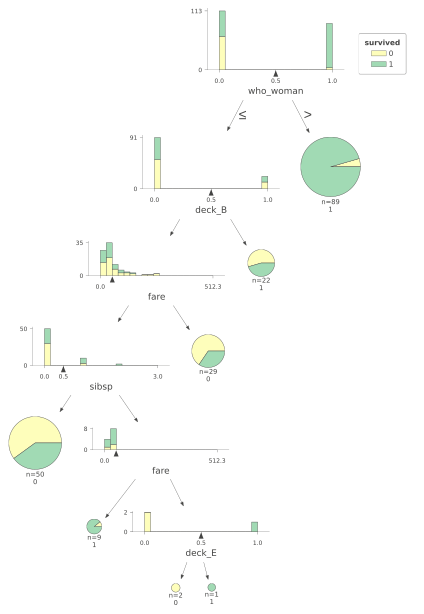

In [124]:
viz_model = dtreeviz.model(
    model,
    X_encoded,
    y_encoded,
    target_name='survived',
    feature_names=X_encoded.columns,
    class_names=list(df['survived'].unique())
)
viz_model.view()